# Exploratory Data Analysis (EDA)

After cleaning and transforming the dataset, the next step is to explore the data to uncover patterns, relationships, and insights.

Exploratory Data Analysis (EDA) helps to:

- Understand the distribution of variables
- Identify relationships between features
- Detect trends and anomalies
- Generate hypotheses for modeling

In this notebook, we analyze bike-sharing demand using statistical summaries and visualizations.

## Import Required Libraries

We use:

- `dplyr`: for data manipulation
- `ggplot2`: for visualization
- `readr`: for loading data

In [1]:
# Load required libraries

# dplyr for data manipulation
library(dplyr)

# ggplot2 for visualization
library(ggplot2)

# readr for reading CSV files
library(readr)


Attaching package: 'dplyr'




The following objects are masked from 'package:stats':

    filter, lag




The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




## Load Clean Dataset

We load the cleaned dataset generated during the data wrangling stage.

In [2]:
# Load cleaned dataset
bike_data <- read_csv("clean_bike_data.csv")

# View first few rows
head(bike_data)

Rows: 8465 Columns: 17


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (4): seasons, holiday, functioning_day, day_of_week
dbl  (12): rented_bike_count, hour, temperature, humidity, wind_speed, visib...
date  (1): date



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


date,rented_bike_count,hour,temperature,humidity,wind_speed,visibility,dew_point_temperature,solar_radiation,rainfall,snowfall,seasons,holiday,functioning_day,year,month,day_of_week
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0,0,0,Winter,No Holiday,Yes,2017,12,Friday
2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0,0,0,Winter,No Holiday,Yes,2017,12,Friday
2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0,0,0,Winter,No Holiday,Yes,2017,12,Friday
2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0,0,0,Winter,No Holiday,Yes,2017,12,Friday
2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0,0,0,Winter,No Holiday,Yes,2017,12,Friday
2017-12-01,100,5,-6.4,37,1.5,2000,-18.7,0,0,0,Winter,No Holiday,Yes,2017,12,Friday


## Dataset Overview

We examine the structure and summary of the dataset to understand variable types and distributions.

In [3]:
# Display structure of dataset
str(bike_data)

# Display summary statistics
summary(bike_data)

spc_tbl_ [8,465 × 17] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ date                 : Date[1:8465], format: "2017-12-01" "2017-12-01" ...
 $ rented_bike_count    : num [1:8465] 254 204 173 107 78 100 181 460 930 490 ...
 $ hour                 : num [1:8465] 0 1 2 3 4 5 6 7 8 9 ...
 $ temperature          : num [1:8465] -5.2 -5.5 -6 -6.2 -6 -6.4 -6.6 -7.4 -7.6 -6.5 ...
 $ humidity             : num [1:8465] 37 38 39 40 36 37 35 38 37 27 ...
 $ wind_speed           : num [1:8465] 2.2 0.8 1 0.9 2.3 1.5 1.3 0.9 1.1 0.5 ...
 $ visibility           : num [1:8465] 2000 2000 2000 2000 2000 ...
 $ dew_point_temperature: num [1:8465] -17.6 -17.6 -17.7 -17.6 -18.6 -18.7 -19.5 -19.3 -19.8 -22.4 ...
 $ solar_radiation      : num [1:8465] 0 0 0 0 0 0 0 0 0.01 0.23 ...
 $ rainfall             : num [1:8465] 0 0 0 0 0 0 0 0 0 0 ...
 $ snowfall             : num [1:8465] 0 0 0 0 0 0 0 0 0 0 ...
 $ seasons              : chr [1:8465] "Winter" "Winter" "Winter" "Winter" ...
 $ holiday              : c

      date            rented_bike_count      hour        temperature    
 Min.   :2017-12-01   Min.   :   2.0    Min.   : 0.00   Min.   :-17.80  
 1st Qu.:2018-02-27   1st Qu.: 214.0    1st Qu.: 6.00   1st Qu.:  3.00  
 Median :2018-05-28   Median : 542.0    Median :12.00   Median : 13.50  
 Mean   :2018-05-28   Mean   : 729.2    Mean   :11.51   Mean   : 12.77  
 3rd Qu.:2018-08-24   3rd Qu.:1084.0    3rd Qu.:18.00   3rd Qu.: 22.70  
 Max.   :2018-11-30   Max.   :3556.0    Max.   :23.00   Max.   : 39.40  
    humidity       wind_speed      visibility   dew_point_temperature
 Min.   : 0.00   Min.   :0.000   Min.   :  27   Min.   :-30.600      
 1st Qu.:42.00   1st Qu.:0.900   1st Qu.: 935   1st Qu.: -5.100      
 Median :57.00   Median :1.500   Median :1690   Median :  4.700      
 Mean   :58.15   Mean   :1.726   Mean   :1434   Mean   :  3.945      
 3rd Qu.:74.00   3rd Qu.:2.300   3rd Qu.:2000   3rd Qu.: 15.200      
 Max.   :98.00   Max.   :7.400   Max.   :2000   Max.   : 27.200      

## Distribution of Target Variable

We analyze the distribution of bike rental counts to understand demand patterns.

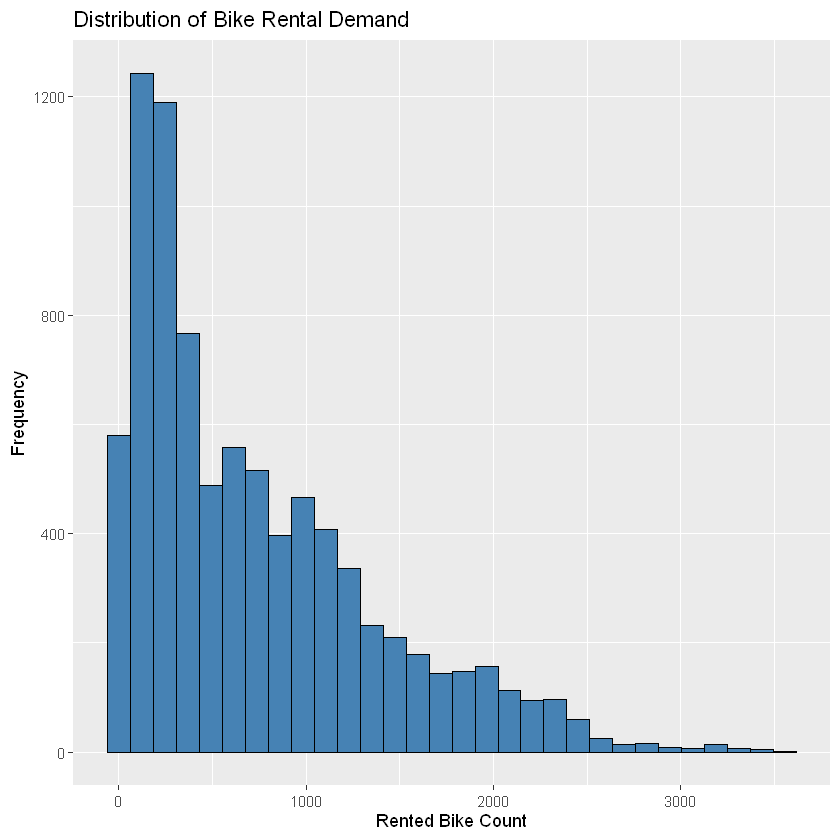

In [4]:
# Plot histogram of bike demand

ggplot(bike_data, aes(x = rented_bike_count)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "black") +
  labs(
    title = "Distribution of Bike Rental Demand",
    x = "Rented Bike Count",
    y = "Frequency"
  )

## Relationship Between Temperature and Bike Demand

Temperature is expected to strongly influence bike-sharing usage.

We visualize this relationship using scatter plots.

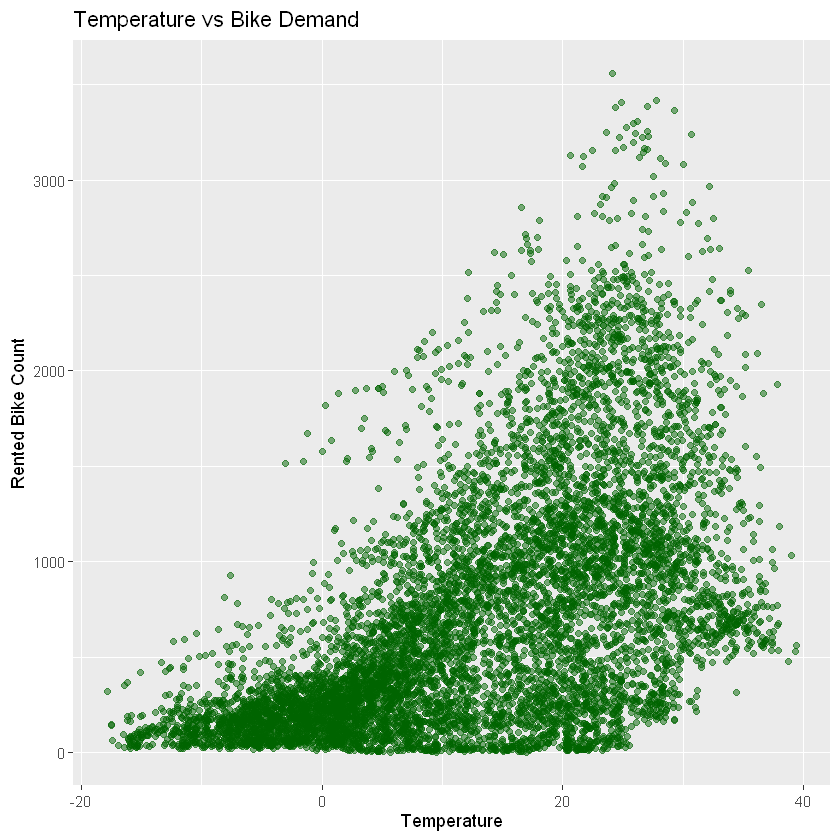

In [5]:
# Scatter plot: temperature vs bike demand

ggplot(bike_data, aes(x = temperature, y = rented_bike_count)) +
  geom_point(alpha = 0.5, color = "darkgreen") +
  labs(
    title = "Temperature vs Bike Demand",
    x = "Temperature",
    y = "Rented Bike Count"
  )

## Relationship Between Humidity and Bike Demand

Humidity is expected to negatively impact bike usage.

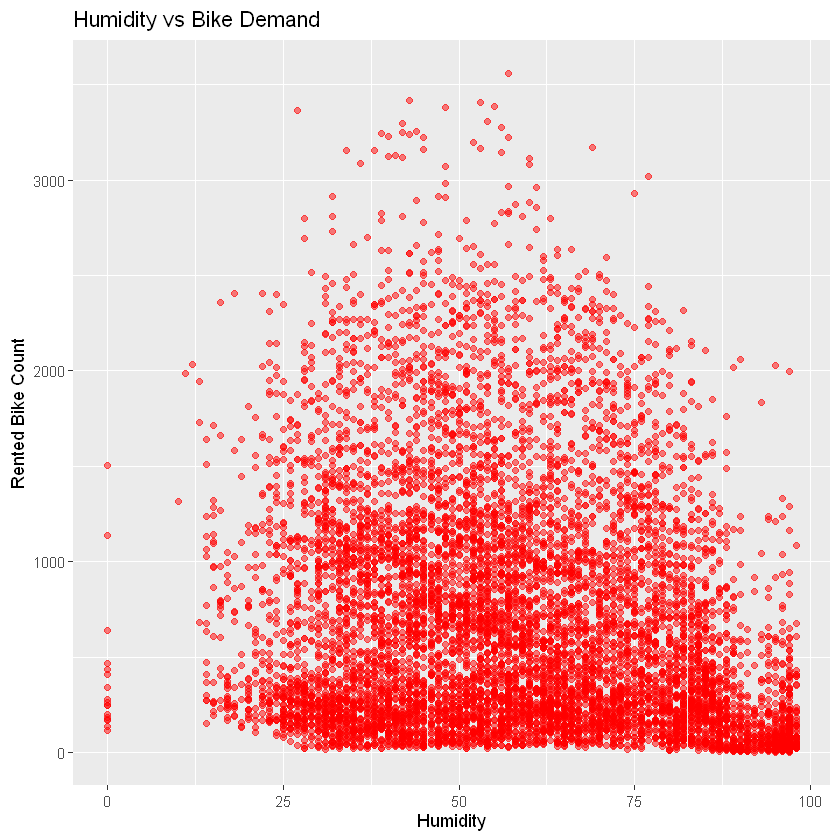

In [6]:
# Scatter plot: humidity vs bike demand

ggplot(bike_data, aes(x = humidity, y = rented_bike_count)) +
  geom_point(alpha = 0.5, color = "red") +
  labs(
    title = "Humidity vs Bike Demand",
    x = "Humidity",
    y = "Rented Bike Count"
  )

## Bike Demand by Hour

Time of day is a critical factor influencing demand.

We analyze demand patterns across different hours.

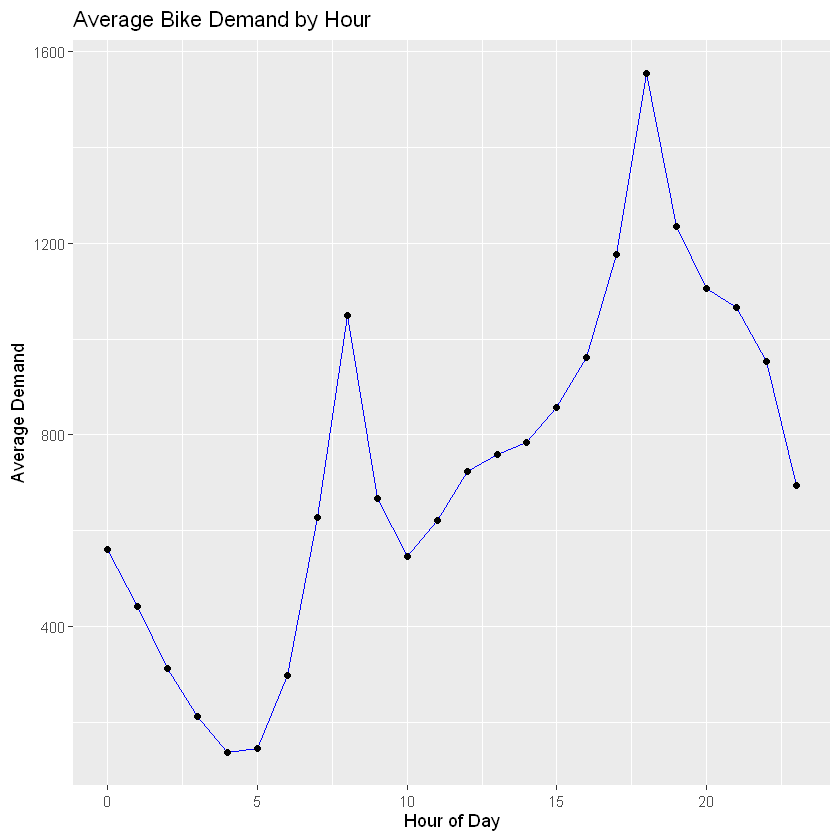

In [7]:
# Aggregate average demand by hour

hourly_data <- bike_data %>%
  group_by(hour) %>%
  summarise(avg_demand = mean(rented_bike_count, na.rm = TRUE))

# Plot line chart

ggplot(hourly_data, aes(x = hour, y = avg_demand)) +
  geom_line(color = "blue") +
  geom_point() +
  labs(
    title = "Average Bike Demand by Hour",
    x = "Hour of Day",
    y = "Average Demand"
  )

## Bike Demand by Season

We analyze how demand varies across seasons.

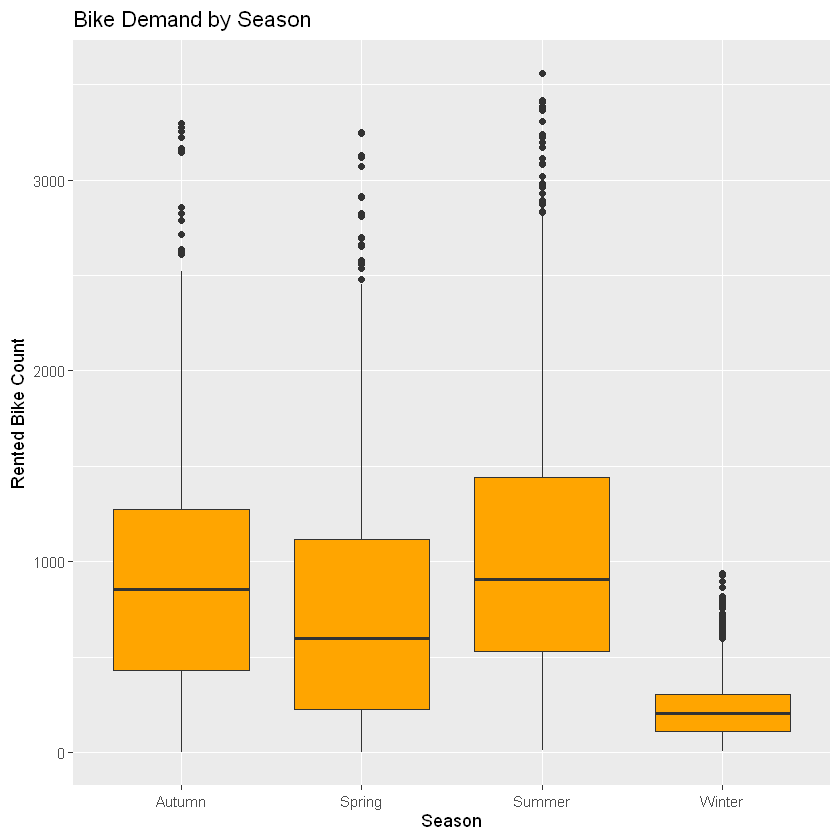

In [8]:
# Boxplot of demand by season

ggplot(bike_data, aes(x = seasons, y = rented_bike_count)) +
  geom_boxplot(fill = "orange") +
  labs(
    title = "Bike Demand by Season",
    x = "Season",
    y = "Rented Bike Count"
  )

## Correlation Analysis

We compute correlations between numerical variables to identify strong relationships.

In [9]:
# Select numeric columns
numeric_data <- bike_data %>%
  select_if(is.numeric)

# Compute correlation matrix
cor_matrix <- cor(numeric_data, use = "complete.obs")

# Display correlation matrix
cor_matrix

,rented_bike_count,hour,temperature,humidity,wind_speed,visibility,dew_point_temperature,solar_radiation,rainfall,snowfall,year,month
rented_bike_count,1.0000000,0.4252558822,0.56280969,-0.20197267,0.125021946,0.21232278,0.400262829,0.27386155,-0.128626093,-0.151610753,0.2320043464,0.167186479
hour,0.4252559,1.0000000000,0.12275854,-0.23593718,0.287779819,0.10386932,0.004691479,0.14465848,0.014344645,-0.022082499,0.0003152846,0.001047699
temperature,0.5628097,0.1227585443,1.00000000,0.16647135,-0.038466393,0.02819978,0.914484639,0.35481036,0.052157639,-0.217738344,0.3769910273,0.213923687
humidity,-0.2019727,-0.2359371795,0.16647135,1.00000000,-0.337352380,-0.54854183,0.539402446,-0.45727269,0.236916912,0.110126502,0.0351877162,0.139090157
wind_speed,0.1250219,0.2877798194,-0.03846639,-0.33735238,1.000000000,0.18042765,-0.177170126,0.32622187,-0.024931327,-0.003789344,-0.0035675003,-0.154149371
visibility,0.2123228,0.1038693183,0.02819978,-0.54854183,0.180427649,1.00000000,-0.182586445,0.15304614,-0.170351798,-0.122859731,0.0518017342,0.063474284
dew_point_temperature,0.4002628,0.0046914787,0.91448464,0.53940245,-0.177170126,-0.18258645,1.000000000,0.09852498,0.126812453,-0.149759793,0.3349849479,0.239406352
solar_radiation,0.2738616,0.1446584822,0.35481036,-0.45727269,0.326221868,0.15304614,0.098524979,1.00000000,-0.074157271,-0.073379874,0.1301410741,-0.028675329
rainfall,-0.1286261,0.0143446451,0.05215764,0.23691691,-0.024931327,-0.17035180,0.126812453,-0.07415727,1.000000000,0.008604092,0.0282282574,0.010911509
snowfall,-0.1516108,-0.0220824988,-0.21773834,0.11012650,-0.003789344,-0.12285973,-0.149759793,-0.07337987,0.008604092,1.000000000,-0.2050301007,0.058410230


## Key Insights

From the analysis:

- Temperature shows a positive relationship with bike demand
- Humidity tends to reduce bike usage
- Demand peaks during specific hours (commuting times)
- Seasonal variations significantly affect demand patterns

These insights guide feature selection and model development.

---

## Author & Acknowledgment

**Author:**  
<span style="color:blue">Deepan Mehta </span>  

**GitHub Profile:**  
https://github.com/deepan-mehta-analytics

This notebook focuses on exploring and understanding the dataset through statistical analysis and visualization techniques.

The workflow is inspired by <span style="color:blue"> IBM Skills Network </span> instructional labs on exploratory data analysis using SQL and ggplot2.

Special acknowledgment is given to:

- <span style="color:blue">Yan Luo  </span>
- <span style="color:blue">Jeff Grossman  </span>
- <span style="color:blue">Rav Ahuja et al. at the IBM Skills Network</span>  

---

## Project Context

This notebook represents the exploratory analysis stage in the end-to-end data science pipeline:

- Data Collection  
- Data Wrangling (ETL)  
- Exploratory Data Analysis (EDA)  
- Model Development  
- Model Evaluation  
- Deployment (R Shiny Dashboard)

---

## Notes

All visualizations and interpretations have been independently structured to highlight meaningful patterns and relationships within the dataset.

---